# 2D Convection-Diffusion Numerical Simulation Visulization

In this notebook, we will explore and compare the results of the 2D numerical simulazation, and eventually visuliza the results.

In [2]:
# Import
import context
from IPython.display import Image
import IPython.display as display
# import plotting package and numerical python package for use in examples later
import matplotlib.pyplot as plt
# import the numpy array handling library
import numpy as np
# import the pde solver for a simple 1-d tank of water with a drop of rain
import adv_dif_2D_arr
import adv_dif_2D_arr_Nflux
import importlib
import matplotlib.colors as colors
import matplotlib.cm as cmx
import matplotlib.colorbar as colorbar

******************************
context imported. Front of path:
/Users/qiujunqi/Desktop/文件/课程/25秋冬/EOSC 511/EOSC511-TheDeepThinkers
back of path: /Users/qiujunqi/MOAD/tools/SalishSeaTools
******************************

through /Users/qiujunqi/Desktop/文件/课程/25秋冬/EOSC 511/EOSC511-TheDeepThinkers/2D code/Visulization_2D/context.py


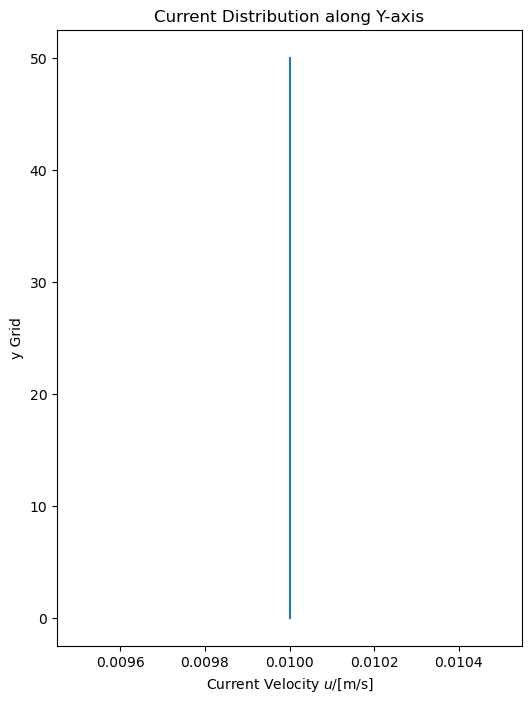

In [3]:
# Run Simulation
#importlib.reload(adv_dif_2D_arr)
importlib.reload(adv_dif_2D_arr_Nflux)

Lx=50
Ly=50
T=1000
n_x = 100
n_y = 100
n_time = 1000
dx = Lx / (n_x-1)
dy = Ly / (n_y-1)
dt = T / (n_time-1)
x = np.linspace(0,Lx,n_x)
y = np.linspace(0,Ly,n_y)
t = np.linspace(0,T,n_time)
#c=adv_dif_2D_arr.adv_dif_2D([n_x, n_y, n_time, Lx, Ly, T])
c=adv_dif_2D_arr_Nflux.adv_dif_2D([n_x, n_y, n_time, Lx, Ly, T])

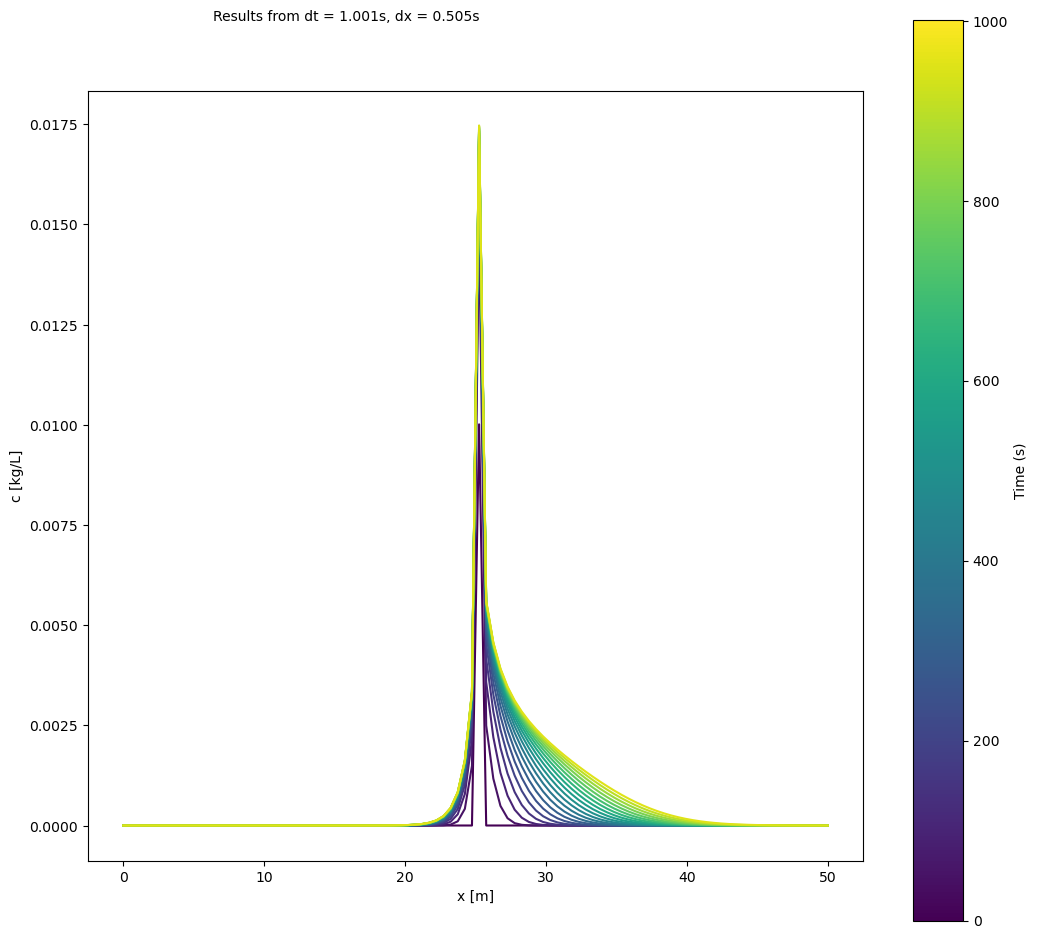

In [4]:
#  
fig, ax_c = plt.subplots(1,1, figsize=(10,10))
the_title = fig.text(0.25, 0.95, 'Results from dt = %.3fs, dx = %.3fs' % (dt, dx))
ax_c.set_ylabel('c [kg/L]')
ax_c.set_xlabel('x [m]')

# We use color to differentiate lines at different times.  Set up the color map
cmap = plt.get_cmap('viridis')
cNorm  = colors.Normalize(vmin=0, vmax=1.*n_time)
cNorm_inseconds = colors.Normalize(vmin=0, vmax=1.*(n_time-1)*dt)
scalarMap = cmx.ScalarMappable(norm=cNorm, cmap=cmap)

# Only try to plot 20 lines, so choose an interval if more than that (i.e. plot every interval lines)
interval = int(np.ceil(n_time/20))

# Do the main plot
for time in range(0, n_time, interval):
    colorVal = scalarMap.to_rgba(time)
    ax_c.plot(x,c[:,0,time], color=colorVal)

# Add the custom colorbar
ax_c = fig.add_axes([0.95, 0.05, 0.05, 0.9])
cb1 = colorbar.ColorbarBase(ax_c, cmap=cmap, norm=cNorm_inseconds)
cb1.set_label('Time (s)')

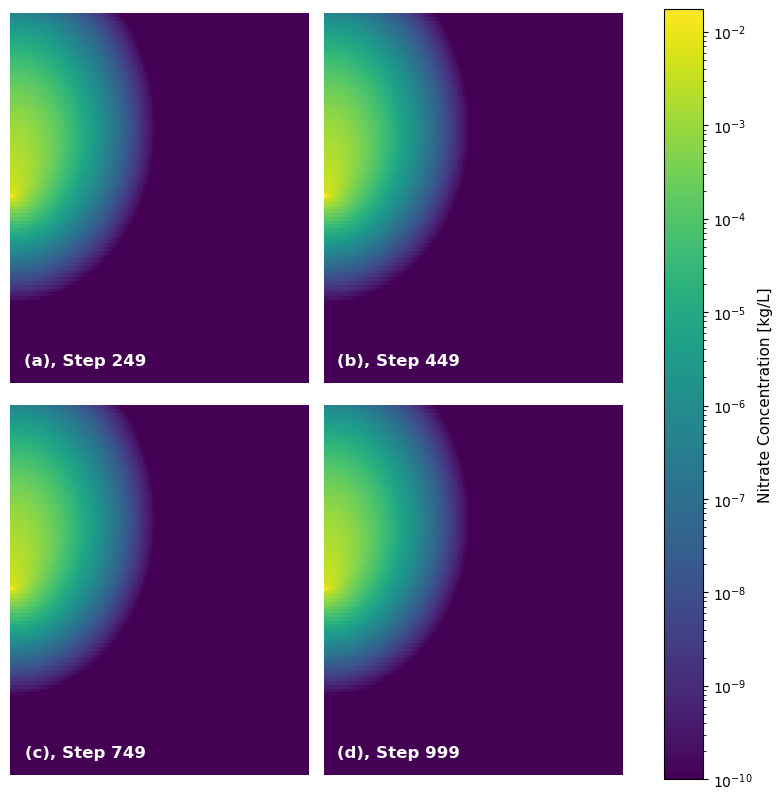

In [49]:
# Visulization

import matplotlib.colors as mcolors

# print(np.shape(c))
# The size would be (100, 100, 1000)

x = np.arange(100)
y = np.arange(100)
X1, Y1 = np.meshgrid(x, y)

minval = np.min(c[:,:,:])
maxval = np.max(c[:,:,:])

# print(minval,maxval)

cmap = cm.viridis
norm = mcolors.LogNorm(vmin=1e-10, vmax=maxval)

fig,axes = plt.subplots(2,2,figsize=(8,8))

tt =[249,449,749,999]
labels = ['(a)', '(b)', '(c)', '(d)']

cc=c[:,:,t]
# cc=cc.swapaxes(0,1)

for ax in axes.flatten():
    t=tt.pop(0)
    label=labels.pop(0)
    ax.axis('off')
    im = ax.pcolormesh(X1, Y1, cc, cmap=cmap, norm=norm, shading='nearest')
    label = label + ', Step %d' %t
    ax.text(0.45, 0.05, label,  transform=ax.transAxes, color='white', fontsize=12, fontweight='bold', va='bottom', ha='right')


plt.tight_layout()


cbar = fig.colorbar(im, ax=axes)
cbar.set_label('Nitrate Concentration [kg/L]', fontsize=11)

plt.show()